In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = sp.symbols('x')
print(x)

x


FUNCTION lagrange_polynomial(x_data, y_data):
    n = length(x_data)
    P(x) = 0
    basis_list = []
    FOR i in 0 to n-1:
        L_i(x) = 1
        FOR j in 0 to n-1:
            IF j != i:
                L_i(x) = L_i(x) * (x - x_data[j]) / (x_data[i] - x_data[j])
        basis_list.append(L_i)
        P(x) = P(x) + y_data[i] * L_i(x)
    RETURN expand(P(x)), basis_list

In [2]:
def lagrange_polynomial(x_data, y_data):
    n = len(x_data)
    P = 0
    basis_list = []
    for i in range(n):
        Li = 1
        for j in range(n):
            if j != i:
                Li *= (x - x_data[j]) / (x_data[i] - x_data[j])
        Li = sp.simplify(Li)
        basis_list.append(Li)
        P += y_data[i] * Li
    return sp.expand(P), basis_list

def verify_basis(basis_list, x_data):
    n = len(x_data)
    print("Verification of L_i(x_j) = delta_ij:")
    for i in range(n):
        row = [sp.nsimplify(basis_list[i].subs(x, x_data[j])) for j in range(n)]
        print(f"L_{i}(x_j) for j=0..{n-1}: {row}")

FOR each of the 5 datasets:
    build P(x) using lagrange_polynomial()
    convert P(x) into a numeric function using sympy.lambdify
    generate a fine x-range spanning that dataset's min/max
    plot the smooth curve
    scatter the original data points

Show all 5 curves + points on one shared figure with a legend

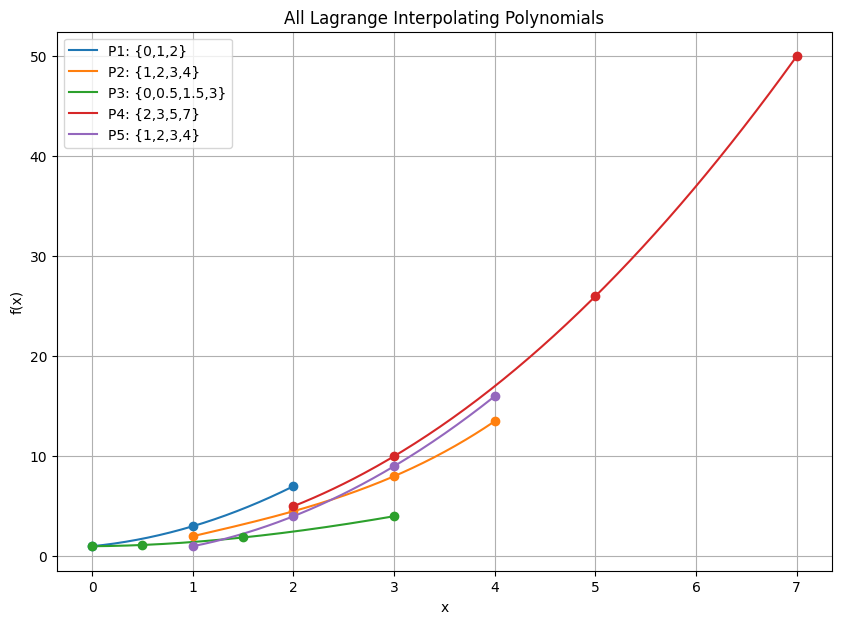

In [3]:
datasets = {
    "P1: {0,1,2}":        ([0, 1, 2],           [1, 3, 7]),
    "P2: {1,2,3,4}":       ([1, 2, 3, 4],        [2.0, 4.5, 8.0, 13.5]),
    "P3: {0,0.5,1.5,3}":   ([0, 0.5, 1.5, 3],    [1.000, 1.125, 1.875, 4.000]),
    "P4: {2,3,5,7}":       ([2, 3, 5, 7],        [5, 10, 26, 50]),
    "P5: {1,2,3,4}":       ([1, 2, 3, 4],        [1, 4, 9, 16]),
}

plt.figure(figsize=(10, 7))

for label, (xd, yd) in datasets.items():
    P, _ = lagrange_polynomial(xd, yd)
    f_num = sp.lambdify(x, P, 'numpy')
    xs = np.linspace(min(xd), max(xd), 200)
    ys = f_num(xs)
    line = plt.plot(xs, ys, label=label)[0]
    plt.scatter(xd, yd, color=line.get_color(), zorder=5)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('All Lagrange Interpolating Polynomials')
plt.legend()
plt.grid(True)
plt.show()

x_data = [0, 1, 2]
y_data = [1, 3, 7]

BUILD P2(x) via lagrange_polynomial(x_data, y_data)
PRINT each L_i(x) symbolically
VERIFY L_i(x_j) = 1 if i==j else 0
EVALUATE P2(1.5)
COMPARE with exact f(x) = x^2 + x + 1 at x=1.5

In [4]:
x_data1 = [0, 1, 2]
y_data1 = [1, 3, 7]

P1, basis1 = lagrange_polynomial(x_data1, y_data1)
print("P2(x) =", P1)

for i, Li in enumerate(basis1):
    print(f"L_{i}(x) =", sp.expand(Li))

verify_basis(basis1, x_data1)

est_1_5 = P1.subs(x, 1.5)
exact_1_5 = 1.5**2 + 1.5 + 1
print(f"\nP2(1.5) = {est_1_5}")
print(f"Exact f(1.5) = x^2+x+1 -> {exact_1_5}")
print(f"Error = {abs(float(est_1_5) - exact_1_5)}")

P2(x) = x**2 + x + 1
L_0(x) = x**2/2 - 3*x/2 + 1
L_1(x) = -x**2 + 2*x
L_2(x) = x**2/2 - x/2
Verification of L_i(x_j) = delta_ij:
L_0(x_j) for j=0..2: [1, 0, 0]
L_1(x_j) for j=0..2: [0, 1, 0]
L_2(x_j) for j=0..2: [0, 0, 1]

P2(1.5) = 4.75000000000000
Exact f(1.5) = x^2+x+1 -> 4.75
Error = 0.0


x_data = [1, 2, 3, 4]
y_data = [2.0, 4.5, 8.0, 13.5]

BUILD P3(x) via lagrange_polynomial(x_data, y_data)
EVALUATE P3(2.5) and P3(3.5)
COMMENT on reasonableness (interpolation vs extrapolation, monotonic trend check)

In [5]:
x_data2 = [1, 2, 3, 4]
y_data2 = [2.0, 4.5, 8.0, 13.5]

P2poly, basis2 = lagrange_polynomial(x_data2, y_data2)
print("P3(x) =", P2poly)

est_2_5 = P2poly.subs(x, 2.5)
est_3_5 = P2poly.subs(x, 3.5)
print(f"\nP3(2.5) = {sp.N(est_2_5)}")
print(f"P3(3.5) = {sp.N(est_3_5)}")

# Both 2.5 and 3.5 lie inside [1,4] -> true interpolation, generally reliable
print("\nBoth points lie within the data range [1,4], so these are interpolations")
print("(not extrapolations) and should be reasonably reliable given the smooth trend.")

P3(x) = 0.166666666666667*x**3 - 0.5*x**2 + 2.83333333333333*x - 0.5

P3(2.5) = 6.06250000000000
P3(3.5) = 10.4375000000000

Both points lie within the data range [1,4], so these are interpolations
(not extrapolations) and should be reasonably reliable given the smooth trend.


x_data = [0, 0.5, 1.5, 3]        # non-uniform spacing
y_data = [1.000, 1.125, 1.875, 4.000]

BUILD P(x) via lagrange_polynomial(x_data, y_data)
EVALUATE P(1), P(2)
EXPLAIN: Lagrange formula needs no fixed step size h,
         unlike Newton forward/backward-difference methods

In [6]:
x_data3 = [0, 0.5, 1.5, 3]
y_data3 = [1.000, 1.125, 1.875, 4.000]

P3, basis3 = lagrange_polynomial(x_data3, y_data3)
print("P(x) =", P3)

est_1 = P3.subs(x, 1)
est_2 = P3.subs(x, 2)
print(f"\nP(1) = {sp.N(est_1)}")
print(f"P(2) = {sp.N(est_2)}")

print("\nLagrange interpolation builds basis polynomials directly from the")
print("x_i values (no assumption of equal spacing), so it handles this")
print("non-uniform grid natively — unlike finite-difference-based methods.")

P(x) = -0.0222222222222221*x**3 + 0.377777777777777*x**2 + 0.0666666666666673*x + 1.0

P(1) = 1.42222222222222
P(2) = 2.46666666666667

Lagrange interpolation builds basis polynomials directly from the
x_i values (no assumption of equal spacing), so it handles this
non-uniform grid natively — unlike finite-difference-based methods.


x_data = [2, 3, 5, 7]
y_data = [5, 10, 26, 50]

BUILD P3(x) via lagrange_polynomial(x_data, y_data)
EVALUATE P3(4), P3(6), P3(8)
DISCUSS reliability: interpolation (inside range) vs extrapolation (outside range)


In [7]:
x_data4 = [2, 3, 5, 7]
y_data4 = [5, 10, 26, 50]

P4, basis4 = lagrange_polynomial(x_data4, y_data4)
print("P3(x) =", P4)

f4 = P4.subs(x, 4)
f6 = P4.subs(x, 6)
f8 = P4.subs(x, 8)
print(f"\nf(4) = {sp.N(f4)}")
print(f"f(6) = {sp.N(f6)}")
print(f"f(8) = {sp.N(f8)}")

print("\nx=4 and x=6 lie inside [2,7] -> interpolation -> more reliable.")
print("x=8 lies outside [2,7] -> extrapolation -> least reliable of the three.")

P3(x) = x**2 + 1

f(4) = 17.0000000000000
f(6) = 37.0000000000000
f(8) = 65.0000000000000

x=4 and x=6 lie inside [2,7] -> interpolation -> more reliable.
x=8 lies outside [2,7] -> extrapolation -> least reliable of the three.


x_data = [1, 2, 3, 4]
y_data = [1, 4, 9, 16]

CHECK student's claim: "4 points -> must be cubic"
BUILD P(x) via lagrange_polynomial(x_data, y_data)
SIMPLIFY and find actual degree
EXPLAIN why degree can be less than n-1 (exact fit to lower-degree function,
         e.g. data actually satisfies f(x) = x^2)

In [8]:
x_data5 = [1, 2, 3, 4]
y_data5 = [1, 4, 9, 16]

P5, basis5 = lagrange_polynomial(x_data5, y_data5)
print("P(x) =", P5)
print("Polynomial degree =", sp.degree(P5, x))
print("\nStudent's claim is false: n data points guarantee a degree of AT MOST n-1.")
print("If the underlying data points lie on a lower-degree curve (like f(x) = x^2),")
print("higher-order terms algebraically cancel out during expansion.")

P(x) = x**2
Polynomial degree = 2

Student's claim is false: n data points guarantee a degree of AT MOST n-1.
If the underlying data points lie on a lower-degree curve (like f(x) = x^2),
higher-order terms algebraically cancel out during expansion.
